# GS20 屈折率,吸収長
参考文献: https://pubs.aip.org/aip/jap/article/124/12/124502/155964/Light-propagation-in-a-neutron-detector-based-on

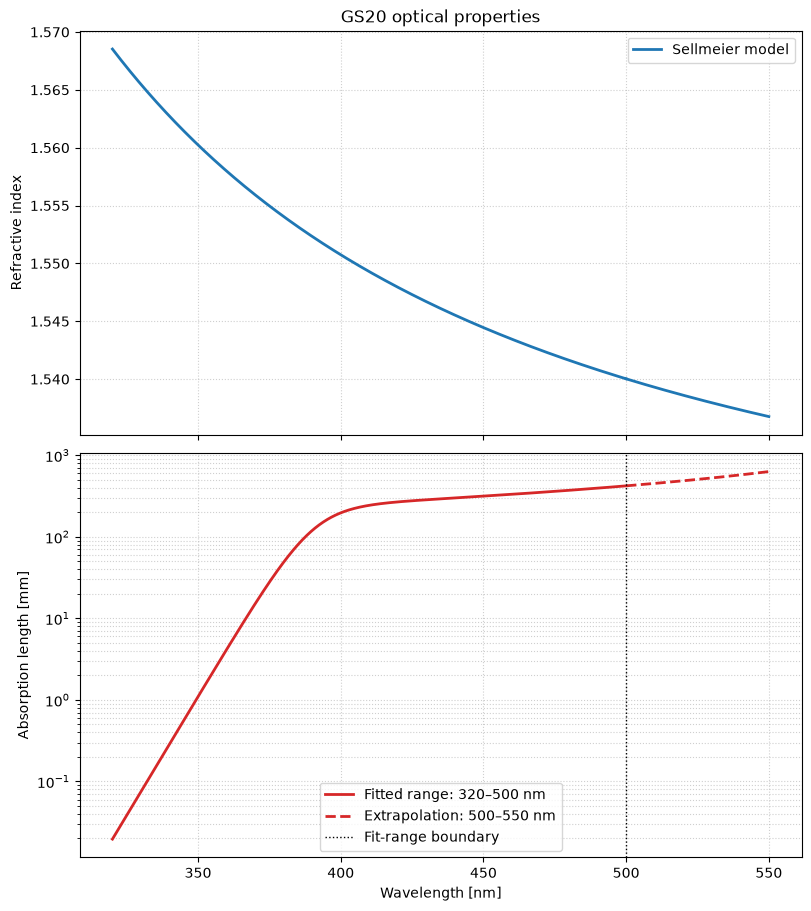

 397.0 nm : n = 1.551208, alpha = 0.056705 cm^-1, L_abs = 176.352 mm
 404.7 nm : n = 1.550047, alpha = 0.044854 cm^-1, L_abs = 222.944 mm
 500.0 nm : n = 1.540025, alpha = 0.023681 cm^-1, L_abs = 422.279 mm


In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# GS20 optical-property parameters
# ============================================================

# Sellmeier coefficients
B1 = 6.6053e-1
C1 = 1.5052e-2  # um^2

B2 = 6.6044e-1
C2 = 3.9310e-3  # um^2

B3 = 7.6303e-1
C3 = 8.8505e1   # um^2


# Absorption-coefficient parameters
A0 = -4.513e-1  # cm^-1
lambda0 = 3.46e-1  # um

A1 = 1.550e1    # cm^-1
l1 = 7.446e-3   # um

A2 = 5.0e-1     # cm^-1
l2 = 3.0        # um


# ============================================================
# Optical-property functions
# ============================================================

def refractive_index(wavelength_nm):
    """
    Calculate the GS20 refractive index using the Sellmeier equation.

    Parameters
    ----------
    wavelength_nm : float or array-like
        Wavelength in nm.

    Returns
    -------
    n : float or ndarray
        Refractive index.
    """
    wavelength_um = np.asarray(wavelength_nm, dtype=float) / 1000.0
    wavelength_sq = wavelength_um**2

    n_sq = (
        1.0
        + B1 * wavelength_sq / (wavelength_sq - C1)
        + B2 * wavelength_sq / (wavelength_sq - C2)
        + B3 * wavelength_sq / (wavelength_sq - C3)
    )

    return np.sqrt(n_sq)


def absorption_coefficient(wavelength_nm):
    """
    Calculate the GS20 absorption coefficient.

    Parameters
    ----------
    wavelength_nm : float or array-like
        Wavelength in nm.

    Returns
    -------
    alpha : float or ndarray
        Absorption coefficient in cm^-1.

    Notes
    -----
    The fitted wavelength range reported in the table is 320--500 nm.
    """
    wavelength_um = np.asarray(wavelength_nm, dtype=float) / 1000.0

    alpha = (
        A0
        + A1 * np.exp(-(wavelength_um - lambda0) / l1)
        + A2 * np.exp(-(wavelength_um - lambda0) / l2)
    )

    return alpha


def absorption_length_mm(wavelength_nm):
    """
    Convert the absorption coefficient into absorption length.

    alpha is in cm^-1:
        L_abs [cm] = 1 / alpha
        L_abs [mm] = 10 / alpha
    """
    alpha = absorption_coefficient(wavelength_nm)

    # Negative or zero alpha is unphysical and can occur if the empirical
    # equation is extrapolated too far outside its fitted range.
    return np.where(alpha > 0.0, 10.0 / alpha, np.nan)


# ============================================================
# Calculate optical properties
# ============================================================

# Valid fitting range for the absorption-coefficient model
wavelength_valid_nm = np.linspace(320.0, 500.0, 1000)

# Optional extrapolation over the long-wavelength emission tail
wavelength_extrapolated_nm = np.linspace(500.0, 550.0, 300)

n_valid = refractive_index(wavelength_valid_nm)
n_extrapolated = refractive_index(wavelength_extrapolated_nm)

abs_length_valid_mm = absorption_length_mm(wavelength_valid_nm)
abs_length_extrapolated_mm = absorption_length_mm(
    wavelength_extrapolated_nm
)


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(8, 9),
    sharex=True,
    constrained_layout=True
)

# Refractive index
axes[0].plot(
    wavelength_valid_nm,
    n_valid,
    color="tab:blue",
    linewidth=2.0,
    label="Sellmeier model"
)

axes[0].plot(
    wavelength_extrapolated_nm,
    n_extrapolated,
    color="tab:blue",
    linewidth=2.0
)

axes[0].set_ylabel("Refractive index")
axes[0].set_title("GS20 optical properties")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend()


# Absorption length
axes[1].plot(
    wavelength_valid_nm,
    abs_length_valid_mm,
    color="tab:red",
    linewidth=2.0,
    label="Fitted range: 320–500 nm"
)

axes[1].plot(
    wavelength_extrapolated_nm,
    abs_length_extrapolated_mm,
    color="tab:red",
    linewidth=2.0,
    linestyle="--",
    label="Extrapolation: 500–550 nm"
)

axes[1].axvline(
    500.0,
    color="black",
    linewidth=1.0,
    linestyle=":",
    label="Fit-range boundary"
)

axes[1].set_xlabel("Wavelength [nm]")
axes[1].set_ylabel("Absorption length [mm]")
axes[1].set_yscale("log")
axes[1].grid(True, which="both", linestyle=":", alpha=0.6)
axes[1].legend()

plt.show()


# ============================================================
# Check representative values
# ============================================================

for wavelength_nm in [397.0, 404.7, 500.0]:
    n = refractive_index(wavelength_nm)
    alpha = absorption_coefficient(wavelength_nm)
    abs_length = absorption_length_mm(wavelength_nm)

    print(
        f"{wavelength_nm:6.1f} nm : "
        f"n = {n:.6f}, "
        f"alpha = {alpha:.6f} cm^-1, "
        f"L_abs = {abs_length:.3f} mm"
    )